Inspeccion estadistica y visual de la señal

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [10]:

# 1. Generación/Carga de Datos (Simulando un sensor con ruido y tendencia)
np.random.seed(42)
# Usamos una ventana de tiempo representativa
tiempo = pd.date_range(start='2026-04-15', periods=500, freq='min')
     
# Señal: Tendencia base + oscilación + ruido gaussiano
valores = np.linspace(10, 50, 500) + np.sin(np.linspace(0, 20, 500))*5 + np.random.normal(0, 2, 500)
# inyectar outlinesrs en los ulitmos 50 valores
valores[450:500] += np.random.uniform(-20, 20, 50)  # Agrega variación extrema
# Inyectar 10 spikes aleatorios con ruido extremo
np.random.seed(42)  # Para reproducibilidad
anomaly_indices = np.random.choice(500, size=10, replace=False)
valores[anomaly_indices] += np.random.normal(0, 15, 10)  # Agrega ruido grande (media 0, std 15)
     
df = pd.DataFrame({'Timestamp': tiempo, 'Lectura': valores})
df.set_index('Timestamp', inplace=True)
   



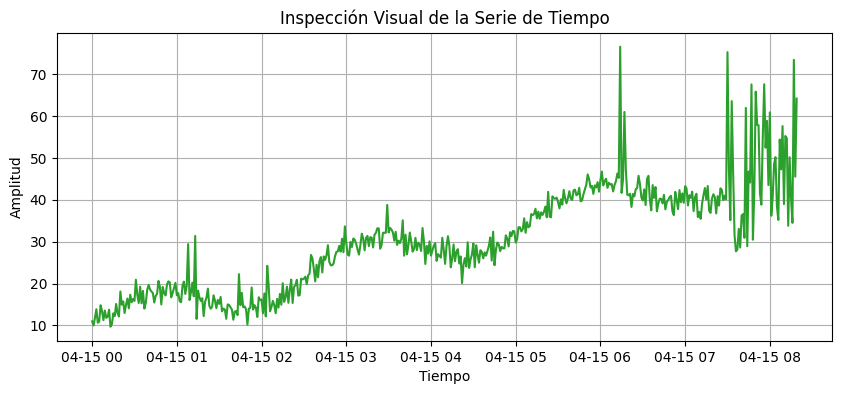

In [11]:
# 2. Inspección Temporal (¿Hay valores atípicos o estacionalidad?)
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Lectura'], label='Señal Cruda del Sensor', color='#2ca02c')
plt.title("Inspección Visual de la Serie de Tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

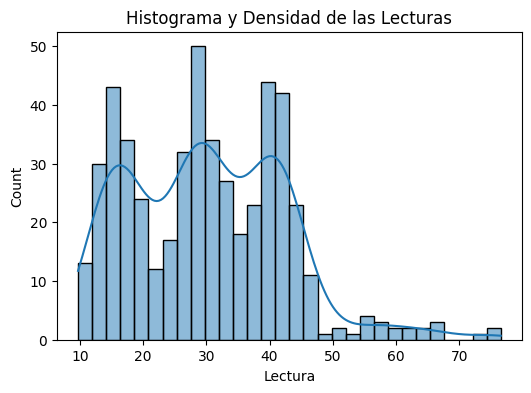

=== Perfil Estadístico del Dataset ===
          Lectura
count  500.000000
mean    30.178596
std     12.273004
min      9.704445
25%     19.222761
50%     29.478756
75%     39.949281
max     76.578800


In [12]:
   
# 3. Análisis de Distribución (¿El ruido es normal?)
plt.figure(figsize=(6, 4))
sns.histplot(df['Lectura'], kde=True, bins=30)
plt.title("Histograma y Densidad de las Lecturas")
plt.show()
   
     # 4. Estadística Descriptiva (El perfil del dataset)
print("=== Perfil Estadístico del Dataset ===")
print(df.describe())